In [22]:
import pandas as pd
import numpy as np 
import sys 
import torch
sys.path.append('../utils/')
from mxnet_utils import *
from nlp_utils import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# Trying MXNet Structure

In [23]:
import pickle

with open("../checkpoints/vocabs.pkl", "rb") as f:
    vocabs = pickle.load(f)

topic_vocab       = vocabs["topic_vocab"]
author_vocab      = vocabs["author_vocab"]
job_vocab         = vocabs["job_vocab"]
location_vocab    = vocabs["location_vocab"]
affiliation_vocab = vocabs["affiliation_vocab"]
label_map         = vocabs["label_map"]

print("Loaded vocabs and label_map.")

Loaded vocabs and label_map.


In [24]:
import random
from transformers import BertModel, BertTokenizer, BertConfig

np.random.seed(100)
torch.manual_seed(100)
random.seed(100)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(100)

bert_dropout = 0.1 # From later in the notebook
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
config = BertConfig.from_pretrained('bert-base-uncased',
                                    hidden_dropout_prob=bert_dropout,
                                    attention_probs_dropout_prob=bert_dropout)
bert_base = BertModel.from_pretrained('bert-base-uncased', config=config)
bert_base.to(device)
print(bert_base)

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

In [25]:
def feature_extraction_transform(data):
    # Transform label into position / negative
    try:
        label, statement, topics, author, job, location, affiliation,cnt_barely, cnt_false, cnt_half, cnt_mostly, cnt_pants_on_fire, venue_context, justification = [str(e) for e in data[2:16]]
    except Exception as e:
        print(f"Error in feature_extraction_transform: {e}, data: {data}")
        return None # Return None to filter out this bad data

    topic_one_encoding = np.zeros(shape=(len(topic_vocab)), dtype=np.float32)
    topic_ids = [topic_vocab[t.strip()] for t in topics.lower().split(',')]
    topic_one_encoding[topic_ids] = 1
    if len(topic_ids) > 0 and topic_one_encoding.sum() > 0:
        topic_one_encoding /= topic_one_encoding.sum()

    author_id = author_vocab[author.lower()]
    job_id = job_vocab[job.lower()]
    location_id = location_vocab[location.lower()]
    affiliation_id = affiliation_vocab[affiliation.lower()]

    try:
        cnt_barely_f = float(cnt_barely)
        cnt_false_f = float(cnt_false)
        cnt_half_f = float(cnt_half)
        cnt_mostly_f = float(cnt_mostly)
        cnt_pants_on_fire_f = float(cnt_pants_on_fire)
    except ValueError:
        # Handle cases where conversion to float fails
        cnt_barely_f = cnt_false_f = cnt_half_f = cnt_mostly_f = cnt_pants_on_fire_f = 0.0

    cnt_total = cnt_barely_f + cnt_false_f + cnt_half_f + cnt_mostly_f + cnt_pants_on_fire_f

    if cnt_total > 0 :
        proportion = [cnt_barely_f / cnt_total,
                      cnt_false_f / cnt_total,
                      cnt_half_f / cnt_total,
                      cnt_mostly_f / cnt_total,
                      cnt_pants_on_fire_f / cnt_total]
    else:
        proportion = [0.0, 0.0, 0.0, 0.0, 0.0]

    cnt_uncertainty = 1.0 / (cnt_total + 1.0)
    history_of_truth = np.array(proportion + [cnt_uncertainty], dtype=np.float32)
    venue_feature = 0 # venue_feature = f(venue_context), keep it as a vector

    return (statement, topic_one_encoding, author_id, job_id, location_id, affiliation_id,
            history_of_truth, venue_feature, label_map[label])

In [26]:
test_dataset_raw = load_tsv_data('../data/liar-plus/test2.tsv')
test_dataset = [d for d in [feature_extraction_transform(data) for data in test_dataset_raw] if d is not None]
test_dataset_bert = [transform_fn(*sample) for sample in test_dataset]
test_data_torch = ListDataset(test_dataset_bert)
test_data = DataLoader(test_data_torch,
                       batch_size=16,
                       shuffle=False,
                       collate_fn=collate_fn,
                       num_workers=0,
                       pin_memory=False)

In [27]:
net_best = BERTClassifier(
    bert=bert_base,
    num_topics=len(topic_vocab),
    num_authors=len(author_vocab),
    num_jobs=len(job_vocab),
    num_locations=len(location_vocab),
    num_affiliations=len(affiliation_vocab),
    num_classes=len(label_map),
    embed_dim=32,
    author_dropout=0.1,
    author_mlp_layers=2,
    author_mlp_hidden=192,
    history_dropout=0.1,
    history_mlp_layers=2,
    history_mlp_hidden=192)

net_best.load_state_dict(torch.load('../checkpoints/best.pth', map_location=device))
net_best.to(device)

BERTClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwis

In [34]:
from sklearn.metrics import confusion_matrix, classification_report

label_map = {
    'false': 0,
    'half-true': 1,
    'mostly-true': 2,
    'true': 3,
    'barely-true': 4,
    'pants-fire': 5
}

tick_labels = [k for k, v in sorted(label_map.items(), key=lambda x: x[1])]

def evaluate_loop_cm(net, eval_data, device):
    net.eval()
    total_num = 0
    hits = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_idx, (inputs, token_types, attention_mask, topic_one_encoding,
                        author_id, job_id, location_id, affiliation_id, history, label) in enumerate(eval_data):

            inputs = inputs.to(device)
            token_types = token_types.to(device)
            attention_mask = attention_mask.to(device)
            label = label.to(device)
            topic_one_encoding = topic_one_encoding.to(device)
            author_id = author_id.to(device)
            job_id = job_id.to(device)
            location_id = location_id.to(device)
            affiliation_id = affiliation_id.to(device)
            history = history.to(device)

            out = net(inputs, token_types, attention_mask, topic_one_encoding,
                      author_id, job_id, location_id, affiliation_id, history)

            preds = out.argmax(dim=-1)

            total_num += preds.size(0)
            hits += (preds == label).sum().item()

            all_preds.append(preds.cpu())
            all_labels.append(label.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    cm = confusion_matrix(all_labels, all_preds)
    cr = classification_report(all_labels, all_preds, target_names=tick_labels)

    accuracy = hits / float(total_num)
    print(cr)

    return accuracy, cm, all_preds, all_labels

test_acc, test_cm, y_pred, _ = evaluate_loop_cm(net_best, test_data, device)
print('Test acc =', test_acc)

              precision    recall  f1-score   support

       false       0.40      0.65      0.49       249
   half-true       0.52      0.32      0.39       212
 mostly-true       0.45      0.44      0.44       265
        true       0.38      0.59      0.46       241
 barely-true       0.89      0.15      0.26       208
  pants-fire       0.67      0.48      0.56        92

    accuracy                           0.44      1267
   macro avg       0.55      0.44      0.44      1267
weighted avg       0.53      0.44      0.43      1267

Test acc = 0.44435674822415155


In [43]:
test_df = open_data('../data/liar-plus/test2.tsv')
test_df = test_df[['statement','label']]
test_df['sent_transformer_label'] = y_pred
display(test_df.head(2))

,statement,label,sent_transformer_label
0,Building a wall on the U.S.-Mexico border will...,true,2
1,Wisconsin is on pace to double the number of l...,false,1


In [44]:
train_dataset_raw = load_tsv_data('../data/liar-plus/train2.tsv')
train_dataset = [d for d in [feature_extraction_transform(data) for data in train_dataset_raw] if d is not None]
train_dataset_bert = [transform_fn(*sample) for sample in train_dataset]
train_data_torch = ListDataset(train_dataset_bert)
train_data = DataLoader(train_data_torch,
                       batch_size=16,
                       shuffle=False,
                       collate_fn=collate_fn,
                       num_workers=0,
                       pin_memory=False)
train_df = open_data('../data/liar-plus/train2.tsv').dropna(subset=['label'])
train_df = train_df[['statement','label']]

train_acc, train_cm, label_train, _ = evaluate_loop_cm(net_best, train_data, device)
train_df['sent_transformer_label'] = label_train
display(train_df.head(2))

              precision    recall  f1-score   support

       false       0.41      0.65      0.50      1995
   half-true       0.11      0.06      0.08      2114
 mostly-true       0.12      0.14      0.13      1962
        true       0.18      0.32      0.23      1676
 barely-true       0.00      0.00      0.00      1654
  pants-fire       0.66      0.37      0.47       839

    accuracy                           0.25     10240
   macro avg       0.25      0.26      0.24     10240
weighted avg       0.21      0.25      0.21     10240



,statement,label,sent_transformer_label
0,Says the Annies List political group supports ...,false,0
1,When did the decline of coal start? It started...,half-true,3


In [46]:
val_dataset_raw = load_tsv_data('../data/liar-plus/val2.tsv')
val_dataset = [d for d in [feature_extraction_transform(data) for data in val_dataset_raw] if d is not None]
val_dataset_bert = [transform_fn(*sample) for sample in val_dataset]
val_data_torch = ListDataset(val_dataset_bert)
val_data = DataLoader(val_data_torch,
                       batch_size=16,
                       shuffle=False,
                       collate_fn=collate_fn,
                       num_workers=0,
                       pin_memory=False)
val_df = open_data('../data/liar-plus/val2.tsv')
val_df = train_df[['statement']]

val_df = open_data('../data/liar-plus/val2.tsv')
val_df = val_df[['statement','label']]
val_acc, val_cm, label_val, _ = evaluate_loop_cm(net_best, val_data, device)
val_df['sent_transformer_label'] = label_val
display(val_df.head(2))

              precision    recall  f1-score   support

       false       0.45      0.67      0.53       263
   half-true       0.10      0.06      0.07       248
 mostly-true       0.14      0.15      0.14       251
        true       0.14      0.31      0.19       169
 barely-true       0.00      0.00      0.00       237
  pants-fire       0.75      0.43      0.55       116

    accuracy                           0.26      1284
   macro avg       0.26      0.27      0.25      1284
weighted avg       0.22      0.26      0.23      1284



,statement,label,sent_transformer_label
0,We have less Americans working now than in the...,barely-true,2
1,"When Obama was sworn into office, he DID NOT u...",pants-fire,5


# Ryan Custom Truth Model

In [29]:
import torch
import torch.nn as nn
from transformers import BertTokenizer, BertModel
import torch.nn.functional as F

state = torch.load("../checkpoints/best.pth", map_location=device)

class CustomTruthModel(nn.Module):
    def __init__(self, pretrained_state_dict=None):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")

        self.topic_embed = nn.Linear(60, 16)
        self.author_embed = nn.Embedding(22, 16)
        self.job_embed = nn.Embedding(22, 16)
        self.location_embed = nn.Embedding(28, 16)
        self.affiliation_embed = nn.Embedding(7, 16)

        self.author_feature_map = nn.Sequential(
            nn.Identity(), 
            nn.Linear(80, 128),
            nn.Identity(),
            nn.Identity(),
            nn.Linear(128, 128)
        )

        self.history_feature_map = nn.Sequential(
            nn.Linear(6, 128),
            nn.Identity(),
            nn.Identity(),
            nn.Linear(128, 128)
        )

        self.classifier = nn.Linear(1024, 6)

        if pretrained_state_dict:
            own_state = self.state_dict()
            for name, param in pretrained_state_dict.items():
                if name in own_state:
                    if own_state[name].shape == param.shape:
                        own_state[name].copy_(param)
            self.load_state_dict(own_state)

    def forward(self, input_ids, attention_mask,
                topic_vec, author_id, job_id, loc_id, aff_id,
                history_vec):
        
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = bert_out.pooler_output

        t = self.topic_embed(topic_vec)
        a = self.author_embed(author_id)
        j = self.job_embed(job_id)
        l = self.location_embed(loc_id)
        f = self.affiliation_embed(aff_id)

        author_feat = torch.cat([t, a, j, l, f], dim=-1)
        author_feat = self.author_feature_map(author_feat)

        hist_feat = self.history_feature_map(history_vec)

        final = torch.cat([cls, author_feat, hist_feat], dim=-1)
        logits = self.classifier(final)
        return logits

In [30]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

pretrained_state_dict = torch.load("../checkpoints/best.pth", map_location=device)


model = CustomTruthModel(pretrained_state_dict=pretrained_state_dict)
model.eval()  

def run_truth_model(article_text, topic_vec=None, author_id=None, job_id=None, loc_id=None, aff_id=None, history_vec=None):
    # convert numpy arrays to tensors automatically
    if isinstance(topic_vec, np.ndarray):
        topic_vec = torch.tensor(topic_vec).unsqueeze(0).float()
    if isinstance(history_vec, np.ndarray):
        history_vec = torch.tensor(history_vec).unsqueeze(0).float()

    if isinstance(author_id, (int, np.integer)):
        author_id = torch.tensor([author_id])
    if isinstance(job_id, (int, np.integer)):
        job_id = torch.tensor([job_id])
    if isinstance(loc_id, (int, np.integer)):
        loc_id = torch.tensor([loc_id])
    if isinstance(aff_id, (int, np.integer)):
        aff_id = torch.tensor([aff_id])
    if topic_vec is None: topic_vec = torch.rand(1, 60)
    if author_id is None: author_id = torch.tensor([1])
    if job_id is None: job_id = torch.tensor([1])
    if loc_id is None: loc_id = torch.tensor([1])
    if aff_id is None: aff_id = torch.tensor([1])
    if history_vec is None: history_vec = torch.rand(1, 6)

    inputs = tokenizer(article_text, return_tensors="pt", truncation=True, padding="max_length", max_length=512)

    with torch.no_grad():
        logits = model(inputs['input_ids'], 
                       inputs['attention_mask'],
                       topic_vec, 
                       author_id, 
                       job_id, 
                       loc_id, 
                       aff_id, 
                       history_vec)
        
        probs = F.softmax(logits, dim=-1)
        pred_idx = torch.argmax(probs, dim=-1).item()

        class_labels = [
            "False",          
            "Half True",      
            "Mostly True",    
            "True",           
            "Barely True",     
            "Pants on Fire"  
            # "NaN"             
        ]
        
        pred_label = class_labels[pred_idx]

    return {
        "logits": logits,
        "probabilities": probs,
        "predicted_label": pred_label
    }

In [31]:
test_outputs = [run_truth_model(statement, topic, aid, jid, lid, afid, hist) for statement, topic, aid, jid, lid, afid, hist, _, _ in test_dataset]

<BarContainer object of 5 artists>

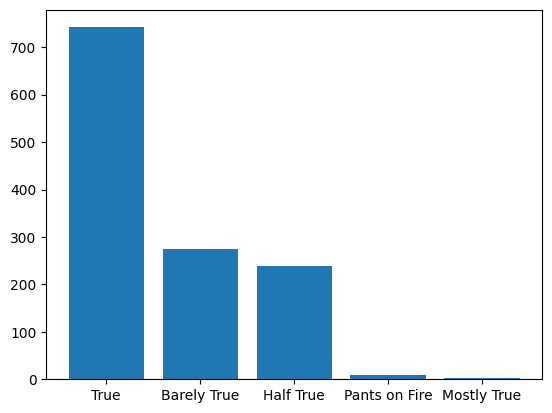

In [32]:
import matplotlib.pyplot as plt

labels = pd.DataFrame(test_outputs)['predicted_label'].value_counts()
plt.bar(labels.index, height=labels)

In [33]:
from sklearn.metrics import classification_report, confusion_matrix
label_map_enc = {v:k.replace('-',' ') for k,v in label_map.items()}
y_test = [label_map_enc[d[-1]] for d in test_dataset]
print(classification_report(y_test,  pd.DataFrame(test_outputs)['predicted_label'].str.lower(), zero_division=0))

               precision    recall  f1-score   support

  barely true       0.16      0.22      0.19       208
        false       0.00      0.00      0.00       249
    half true       0.13      0.14      0.13       212
  mostly true       0.33      0.00      0.01       265
   pants fire       0.00      0.00      0.00        92
pants on fire       0.00      0.00      0.00         0
         true       0.15      0.46      0.23       241

     accuracy                           0.15      1267
    macro avg       0.11      0.12      0.08      1267
 weighted avg       0.15      0.15      0.10      1267



# Spam Score

In [51]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.preprocessing import MinMaxScaler
import torch
import pandas as pd

spam_model_name = "mrm8488/bert-tiny-finetuned-sms-spam-detection"
spam_tokenizer = AutoTokenizer.from_pretrained(spam_model_name)
spam_model = AutoModelForSequenceClassification.from_pretrained(spam_model_name)
spam_model.eval()

def get_spam_scores(text_list, batch_size=16):
    scores = []
    for i in range(0, len(text_list), batch_size):
        batch = text_list[i:i+batch_size]
        inputs = spam_tokenizer(
            batch,
            return_tensors="pt",
            truncation=True,
            padding="max_length",
            max_length=512
        )
        with torch.no_grad():
            outputs = spam_model(**inputs)
            probs = torch.softmax(outputs.logits, dim=1)
            scores.extend(probs[:, 1].tolist())
    return scores

train_df['spam_score'] = get_spam_scores(train_df['statement'].tolist())
test_df['spam_score'] = get_spam_scores(test_df['statement'].tolist())
val_df['spam_score'] = get_spam_scores(val_df['statement'].tolist())

spam_scaler = MinMaxScaler(feature_range=(0,10))
train_df['spam_score'] = spam_scaler.fit_transform(train_df[['spam_score']])
val_df['spam_score'] = spam_scaler.transform(val_df[['spam_score']])   
test_df['spam_score'] = spam_scaler.transform(test_df[['spam_score']])

# Political Affiliation

In [52]:
import spacy
# spacy.cli.download("en_core_web_md")
datum = train_df.iloc[0]
nlp = spacy.load("en_core_web_md")
doc = nlp(datum['statement'])
doc.vector.shape
statistic_types = {'CARDINAL', 'PERCENT', 'MONEY', 'QUANTITY'}

def stat_counter(text):
    if not isinstance(text, str):
        return 0
    doc = nlp(text)
    counter = 0
    for ent in doc.ents: 
        if ent.label_ in statistic_types:
            counter += 1
    return counter

from rapidfuzz import fuzz
conservative_bigrams = pd.read_csv('../data/top_conservative_bigrams.csv')['bigram']
liberal_bigrams = pd.read_csv('../data/top_liberal_bigrams.csv')['bigram']
def match_counter(statement, bigram_list, threshold):
    stat = nlp(str(statement))
    word = [word.text.lower() for word in stat]
    bigram_coll = [''.join(word[i:i+2]) for i in range(len(word)-1)]
    matches = 0
    for bigram in bigram_coll:
        for check in bigram_list:
            if fuzz.ratio(bigram, check) >= threshold:
                matches += 1
                break

    return matches


train_df['statistic_count'] = train_df['statement'].apply(stat_counter)
train_df['conservative_bigram_count'] = train_df['statement'].apply(
    lambda x: match_counter(x, conservative_bigrams, threshold=70)
)
train_df['liberal_bigram_count'] = train_df['statement'].apply(
    lambda x: match_counter(x, liberal_bigrams, threshold=70)
)

val_df['statistic_count'] = val_df['statement'].apply(stat_counter)
val_df['conservative_bigram_count'] = val_df['statement'].apply(
    lambda x: match_counter(x, conservative_bigrams, threshold=70)
)
val_df['liberal_bigram_count'] = val_df['statement'].apply(
    lambda x: match_counter(x, liberal_bigrams, threshold=70)
)

test_df['statistic_count'] = test_df['statement'].apply(stat_counter)
test_df['conservative_bigram_count'] = test_df['statement'].apply(
    lambda x: match_counter(x, conservative_bigrams, threshold=70)
)
test_df['liberal_bigram_count'] = test_df['statement'].apply(
    lambda x: match_counter(x, liberal_bigrams, threshold=70)
)

count_features = ["statistic_count", "conservative_bigram_count", "liberal_bigram_count"]
scaler_counts = MinMaxScaler(feature_range=(0,10))

train_df[count_features] = scaler_counts.fit_transform(train_df[count_features])
val_df[count_features]   = scaler_counts.transform(val_df[count_features])
test_df[count_features]  = scaler_counts.transform(test_df[count_features])

# Sensationalism

In [53]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def emotional_intensity_vader(text):
    if not isinstance(text, str):
        return 0.0
    if len(text) == 0:
        return 0.0
    vs = analyzer.polarity_scores(text)
    return abs(vs['compound'])

for df in [train_df, test_df, val_df]:
    df['emotional_intensity'] = df['statement'].apply(emotional_intensity_vader)

scaler_vader = MinMaxScaler(feature_range=(0,10))
train_df["emotional_intensity"] = scaler_vader.fit_transform(train_df[["emotional_intensity"]])
val_df["emotional_intensity"]   = scaler_vader.transform(val_df[["emotional_intensity"]])
test_df["emotional_intensity"]  = scaler_vader.transform(test_df[["emotional_intensity"]])

# Complete Model

In [59]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

X_train, y_train = train_df.drop(columns=['statement','label']), train_df['label']
X_test, y_test = test_df.drop(columns=['statement','label']), test_df['label']

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

clf = RandomForestClassifier(n_estimators=200, max_depth=7)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.52      0.31      0.39       212
           1       0.40      0.65      0.50       249
           2       0.45      0.44      0.44       265
           3       0.38      0.59      0.46       241
           4       0.66      0.46      0.54        92
           5       0.84      0.15      0.26       208

    accuracy                           0.44      1267
   macro avg       0.54      0.43      0.43      1267
weighted avg       0.52      0.44      0.42      1267

